# Modeling

In [ ]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, make_scorer, roc_curve, ConfusionMatrixDisplay, fbeta_score,
                             confusion_matrix, classification_report, average_precision_score, 
                             balanced_accuracy_score)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from xgboost import XGBClassifier

In [2]:
DATA_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data"
df = pd.read_csv(os.path.join(DATA_DIR, "heart_failure_clinical_records_dataset.csv"))

In [3]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 12)
y shape: (299,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (239, 12)
X_test: (60, 12)


In [5]:
print("Train target distribution:")
print(y_train.value_counts())

print("\nTrain target proportion:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest target proportion:")
print(y_test.value_counts(normalize=True))

Train target distribution:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

Train target proportion:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
DEATH_EVENT
0    41
1    19
Name: count, dtype: int64

Test target proportion:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [6]:
def build_preprocessor(include_time=True):
    log_cols = ["creatinine_phosphokinase", "serum_creatinine", "platelets"]

    if include_time:
        log_cols.append("time")
    
    scale_cols = ["age", "ejection_fraction", "serum_sodium"]
    bin_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

    log_pipeline = Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler())
    ])
    
    scale_pipeline = Pipeline([
        ("scale", StandardScaler())
    ])

    return ColumnTransformer([
        ("log", log_pipeline, log_cols),
        ("scale", scale_pipeline, scale_cols),
        ("pass", "passthrough", bin_cols)
    ], verbose_feature_names_out=False)

## Cross Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "AUC": make_scorer(roc_auc_score, response_method="predict_proba"),
    "F1": make_scorer(f1_score, zero_division=0),
    "PRE": make_scorer(precision_score, zero_division=0),
    "REC": make_scorer(recall_score, zero_division=0),
}

def cv_table(X, y, models):
    rows = []
    for name, model in models.items():
        r = {m: cross_val_score(model, X, y, cv=cv, scoring=s).mean().round(4)
             for m, s in scorers.items()}
        r |= {"model": name}; rows.append(r)
    return pd.DataFrame(rows).set_index("model")

In [8]:
preprocessor = build_preprocessor(include_time=True)

def make_model(est, include_time=True):
    return Pipeline([
        ("pre", build_preprocessor(include_time=include_time)),
        ("model", est)
    ])

In [9]:
models = {
    "LogReg": make_model(LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
    "RandomForest": make_model(RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
    "SVM": make_model(CalibratedClassifierCV(SVC(kernel="rbf", class_weight="balanced"), ensemble=False)),
    "kNN": make_model(KNeighborsClassifier(n_neighbors=5)),
    "GradientBoosting": make_model(GradientBoostingClassifier(random_state=42)),
    "XGBoost": make_model(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
}
result = cv_table(X_train, y_train, models)
print(result.round(4).sort_values("AUC", ascending=False))

                     AUC      F1     PRE     REC
model                                           
XGBoost           0.9109  0.7246  0.8013  0.6750
RandomForest      0.9078  0.7443  0.7424  0.7550
LogReg            0.9038  0.7932  0.7730  0.8175
GradientBoosting  0.8972  0.7036  0.7616  0.6642
SVM               0.8956  0.7477  0.7616  0.7400
kNN               0.8315  0.5399  0.8167  0.4167


In [10]:
top3_names = (result.sort_values("AUC", ascending=False).head(3).index.tolist())

print("Top 3 models:")
print(top3_names)

Top 3 models:
['XGBoost', 'RandomForest', 'LogReg']


Based on 5-fold cross-validation result, the top three models (XGBoost, Random Forest, and Logistic Regression) will be selected for hyperparameter tuning.

## Hyperparameter Tuning

In [11]:
param_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [12]:
grid_lr = GridSearchCV(
    make_model(LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
    param_grid=param_lr,
    cv=cv, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_train, y_train)
print("Best param:", grid_lr.best_params_)
print("Best CV AUC:", grid_lr.best_score_.round(4))

Best param: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV AUC: 0.9091


d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [13]:
grid_rf = GridSearchCV(
    make_model(RandomForestClassifier(random_state=42, class_weight="balanced")),
    param_grid=param_rf,
    cv=cv, scoring="roc_auc", n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Best param:", grid_rf.best_params_)
print("Best CV AUC:", grid_rf.best_score_.round(4))

Best param: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV AUC: 0.9154


In [14]:
grid_xgb = GridSearchCV(
    make_model(XGBClassifier(random_state=42, eval_metric="logloss")),
    param_grid=param_xgb,
    cv=cv, scoring="roc_auc", n_jobs=1
)

grid_xgb.fit(X_train, y_train)

print("Best param:", grid_xgb.best_params_)
print("Best CV AUC:", grid_xgb.best_score_.round(4))

Best param: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV AUC: 0.9218


## Tuned Model Comparison

In [15]:
tuned_results = []

if "LogReg" in top3_names:
    tuned_results.append({
        "Model": "LogReg",
        "Best CV AUC": grid_lr.best_score_,
        "Best Parameters": grid_lr.best_params_
    })

if "RandomForest" in top3_names:
    tuned_results.append({
        "Model": "RandomForest",
        "Best CV AUC": grid_rf.best_score_,
        "Best Parameters": grid_rf.best_params_
    })

if "XGBoost" in top3_names:
    tuned_results.append({
        "Model": "XGBoost",
        "Best CV AUC": grid_xgb.best_score_,
        "Best Parameters": grid_xgb.best_params_
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.sort_values("Best CV AUC", ascending=False).round(4)

,Model,Best CV AUC,Best Parameters
2,XGBoost,0.9218,"{'model__colsample_bytree': 0.8, 'model__learn..."
1,RandomForest,0.9154,"{'model__max_depth': 10, 'model__min_samples_l..."
0,LogReg,0.9091,"{'model__C': 0.1, 'model__penalty': 'l2'}"


In [16]:
final_models = {
    "LogReg": grid_lr.best_estimator_,
    "RandomForest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}
res_final = cv_table(X_train, y_train, final_models)
print(res_final.sort_values("AUC", ascending=False))

d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  war

                 AUC      F1     PRE     REC
model                                       
XGBoost       0.9218  0.7638  0.8079  0.7283
RandomForest  0.9154  0.7469  0.7334  0.7675
LogReg        0.9091  0.7823  0.7526  0.8175


Based on 5-fold cross-validation, XGBoost was selected as the main candidate model. The impact of the `time` feature is evaluated separately because `time` represents the follow-up period and may not be available at the time of baseline prediction.

In [17]:
def select_recall_threshold(y_true, y_proba, target_recall=0.80):
    thresholds = np.arange(0.05, 0.96, 0.01)
    threshold_results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        threshold_results.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

    threshold_df = pd.DataFrame(threshold_results)
    eligible = threshold_df[threshold_df["recall"] >= target_recall]

    if not eligible.empty:
        best_t = eligible.sort_values(["precision", "f2"], ascending=False).iloc[0]["threshold"]
    else:
        best_t = threshold_df.sort_values(["recall", "f2"], ascending=False).iloc[0]["threshold"]

    selected = threshold_df.iloc[(threshold_df["threshold"] - best_t).abs().argmin()].copy()

    return float(best_t), threshold_df, selected

In [18]:
target_recall = 0.80
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count
scale_pos_weight_values = sorted(set([1.0, 1.5, 2.0, round(float(class_ratio), 2), 2.5, 3.0]))

print("Negative samples:", neg_count)
print("Positive samples:", pos_count)
print("Class ratio:", round(class_ratio, 4))
print("Scale_pos_weight candidates:", scale_pos_weight_values)

Negative samples: 162
Positive samples: 77
Class ratio: 2.1039
Scale_pos_weight candidates: [1.0, 1.5, 2.0, 2.1, 2.5, 3.0]


In [19]:
candidate_results = []

for weight in scale_pos_weight_values:
    candidate_model = clone(grid_xgb.best_estimator_)
    candidate_model.set_params(model__scale_pos_weight=weight)
    candidate_oof = cross_val_predict(candidate_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]

    candidate_best_t, candidate_threshold_df, candidate_selected = (
        select_recall_threshold(y_train, candidate_oof, target_recall=target_recall)
    )

    candidate_results.append({
        "scale_pos_weight": weight,
        "oof_auc": roc_auc_score(y_train, candidate_oof),
        "best_threshold": candidate_best_t,
        "oof_precision": candidate_selected["precision"],
        "oof_recall": candidate_selected["recall"],
        "oof_f1": candidate_selected["f1"],
        "oof_f2": candidate_selected["f2"]
    })

candidate_results_df = pd.DataFrame(candidate_results)
display(candidate_results_df.sort_values(
    ["oof_recall", "oof_precision", "oof_f2"],
    ascending=False
).round(4))

,scale_pos_weight,oof_auc,best_threshold,oof_precision,oof_recall,oof_f1,oof_f2
2,2.0,0.9089,0.47,0.7381,0.8052,0.7702,0.7908
0,1.0,0.9105,0.33,0.7294,0.8052,0.7654,0.7888
3,2.1,0.9117,0.47,0.7294,0.8052,0.7654,0.7888
4,2.5,0.9093,0.49,0.7294,0.8052,0.7654,0.7888
1,1.5,0.9097,0.40,0.7209,0.8052,0.7607,0.7868
5,3.0,0.9071,0.52,0.7209,0.8052,0.7607,0.7868


In [20]:
eligible_candidates = candidate_results_df[candidate_results_df["oof_recall"] >= target_recall]

if not eligible_candidates.empty:
    winner = eligible_candidates.sort_values(
        ["oof_precision", "oof_f2", "oof_auc"],
        ascending=False
    ).iloc[0]
else:
    winner = candidate_results_df.sort_values(
        ["oof_recall", "oof_f2", "oof_auc"],
        ascending=False
    ).iloc[0]

best_scale_pos_weight = float(winner["scale_pos_weight"])

print("Selected scale_pos_weight:", best_scale_pos_weight)
display(winner.to_frame().T.round(4))

Selected scale_pos_weight: 2.0


,scale_pos_weight,oof_auc,best_threshold,oof_precision,oof_recall,oof_f1,oof_f2
2,2.0,0.9089,0.47,0.7381,0.8052,0.7702,0.7908


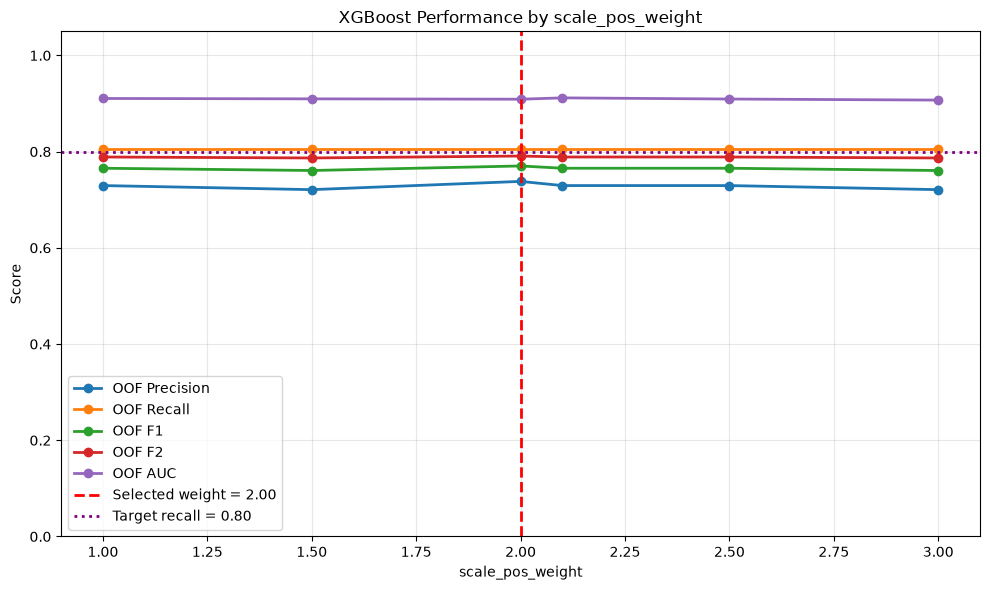

In [21]:
plot_df = candidate_results_df.sort_values("scale_pos_weight")
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = {
    "oof_precision": "OOF Precision",
    "oof_recall": "OOF Recall",
    "oof_f1": "OOF F1",
    "oof_f2": "OOF F2",
    "oof_auc": "OOF AUC"
}

for column, label in metrics_to_plot.items():
    ax.plot(plot_df["scale_pos_weight"], plot_df[column], marker="o", linewidth=2, label=label)

ax.axvline(best_scale_pos_weight,color="red",linestyle="--",linewidth=2,label=(
        f"Selected weight = "
        f"{best_scale_pos_weight:.2f}"
        ))
ax.axhline(target_recall, color="purple", linestyle=":", linewidth=2, label=f"Target recall = {target_recall:.2f}")
ax.set_title("XGBoost Performance by scale_pos_weight")
ax.set_xlabel("scale_pos_weight")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
best_model = clone(grid_xgb.best_estimator_)
best_model.set_params(model__scale_pos_weight=best_scale_pos_weight)
best_model.fit(X_train, y_train)

print("Best model: XGBoost")
print("Selected scale_pos_weight:", best_scale_pos_weight)
print("Original best CV AUC:", round(grid_xgb.best_score_, 4))

Best model: XGBoost
Selected scale_pos_weight: 2.0
Original best CV AUC: 0.9218


In [23]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test AUC: 0.8858
Test F1: 0.7647
Test Precision: 0.8667
Test Recall: 0.6842


## Threshold Optimization
F1, Precision, and Recall depend on the decision cut-off. With imbalanced data (68:32), the default threshold of 0.5 is rarely optimal. <br>
The threshold is selected based on out-of-fold (OOF) CV, not the test set, to ensure the cut-off selection is unbiased. AUC is unaffected by the threshold.

In [24]:
oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
best_t, threshold_df, selected = (select_recall_threshold(y_train, oof, target_recall=target_recall))

In [25]:
print(f"Target recall: {target_recall:.2f}")
print(f"Selected threshold: {best_t:.2f}")

display(selected.to_frame().T.round(4))

Target recall: 0.80
Selected threshold: 0.47


,threshold,precision,recall,f1,f2
42,0.47,0.7381,0.8052,0.7702,0.7908


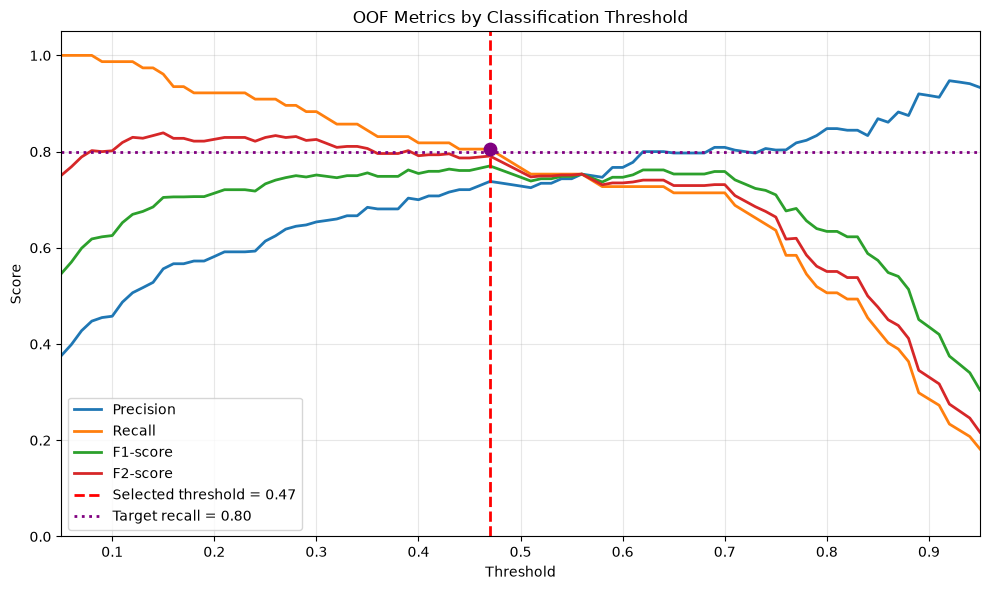

In [26]:
plot_df = threshold_df.sort_values("threshold")

fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "f2": "F2-score"
}

for column, label in metrics_to_plot.items():
    ax.plot(plot_df["threshold"], plot_df[column], linewidth=2, label=label)

ax.axvline(best_t, color="red", linestyle="--", linewidth=2, label=f"Selected threshold = {best_t:.2f}")
ax.axhline(target_recall, color="purple", linestyle=":", linewidth=2, label=f"Target recall = {target_recall:.2f}")
ax.scatter(best_t, selected["recall"], color="purple", s=80, zorder=5)
ax.set_title("OOF Metrics by Classification Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
y_pred_default = (y_proba >= 0.50).astype(int)
y_pred_opt = (y_proba >= best_t).astype(int)

rows = []
for name, yp in [("default (0.5)", y_pred_default),
                 (f"recall-optimized ({best_t:.2f})", y_pred_opt)]:
    rows.append({"threshold": name,
                 "F1": f1_score(y_test, yp, zero_division=0),
                 "Precision": precision_score(y_test, yp, zero_division=0),
                 "Recall": recall_score(y_test, yp, zero_division=0)})

test_threshold_results = pd.DataFrame(rows)
display(test_threshold_results.round(4))
print("Test AUC:", round(test_auc, 4))

,threshold,F1,Precision,Recall
0,default (0.5),0.7647,0.8667,0.6842
1,recall-optimized (0.47),0.7429,0.8125,0.6842


Test AUC: 0.8858


## Results Visualization

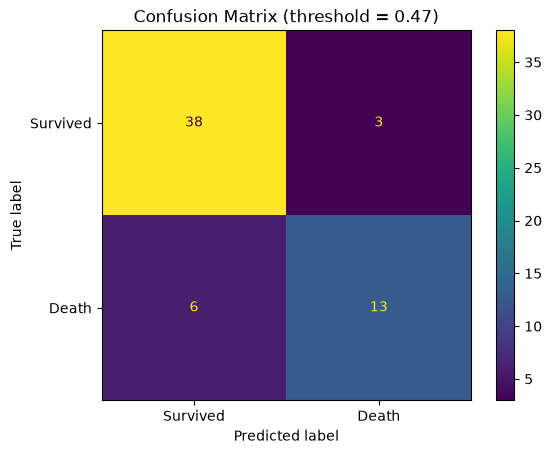

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["Survived", "Death"])
plt.title(f"Confusion Matrix (threshold = {best_t:.2f})")
plt.show()

The confusion matrix employs a threshold selected based on the target recall derived from OOF probabilities. Evaluation on the test set is used to measure the model's final performance.

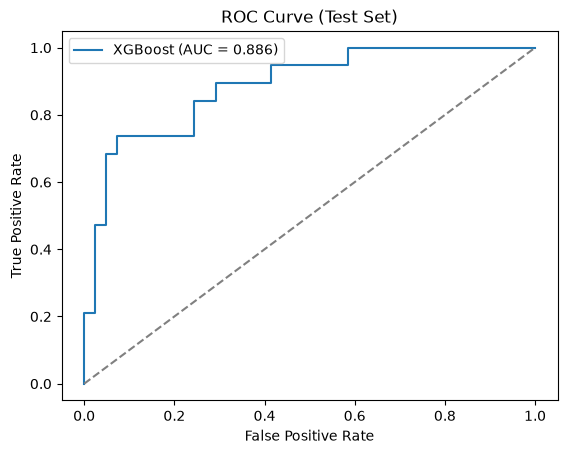

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve (Test Set)")
plt.show()

The XGBoost ROC curve on the test set yielded an AUC of 0.886. This result is based on the XGBoost model using the selected `scale_pos_weight`.

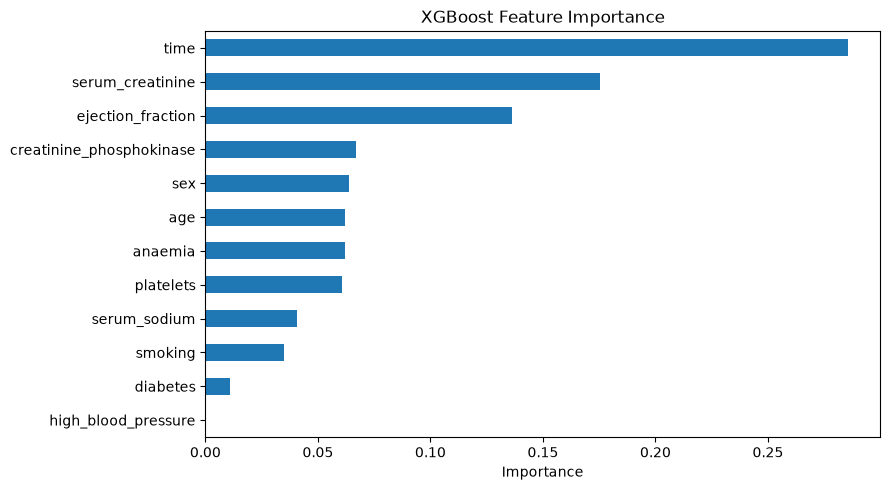

In [30]:
steps = list(best_model.named_steps)
model_step = best_model.named_steps[steps[-1]]
pre_step = best_model.named_steps[steps[0]] 

if hasattr(model_step, "feature_importances_"):
    feature_names = pre_step.get_feature_names_out()
    imp = pd.Series(model_step.feature_importances_, index=feature_names).sort_values()
    imp.plot(kind="barh", figsize=(9, 5))
    plt.title("XGBoost Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

Feature importance is compared between the models with and without `time`. Because `time` represents the follow-up period, its contribution should be interpreted separately from baseline clinical features.

## Tuning XGBoost without `time` feature

In [32]:
X_train_no_time = X_train.drop(columns=["time"])
X_test_no_time = X_test.drop(columns=["time"])

print("Train with time:", X_train.shape)
print("Train without time:", X_train_no_time.shape)
print("Test with time:", X_test.shape)
print("Test without time:", X_test_no_time.shape)

Train with time: (239, 12)
Train without time: (239, 11)
Test with time: (60, 12)
Test without time: (60, 11)


In [34]:
grid_xgb_no_time = GridSearchCV(
    make_model(
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        include_time=False
    ),
    param_grid=param_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

grid_xgb_no_time.fit(X_train_no_time, y_train)

print("Best parameters without time:")
print(grid_xgb_no_time.best_params_)
print("Best CV AUC without time:", round(grid_xgb_no_time.best_score_, 4))

Best parameters without time:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV AUC without time: 0.7946


In [35]:
model_no_time = clone(grid_xgb_no_time.best_estimator_)
model_no_time.set_params(model__scale_pos_weight=best_scale_pos_weight)
model_no_time.fit(X_train_no_time, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['age','anaemia','creatinine_phosphokinase',...,'serum_sodium','sex', 'smoking']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('scale', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to set

In [36]:
no_time_oof_proba = cross_val_predict(
    model_no_time,
    X_train_no_time,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

no_time_threshold, no_time_threshold_df, no_time_selected = (
    select_recall_threshold(
        y_train,
        no_time_oof_proba,
        target_recall=target_recall
    )
)

In [37]:
no_time_test_proba = model_no_time.predict_proba(X_test_no_time)[:, 1]
no_time_pred_default = (no_time_test_proba >= 0.50).astype(int)
no_time_pred_optimized = (no_time_test_proba >= no_time_threshold).astype(int)
no_time_test_auc = roc_auc_score(y_test, no_time_test_proba)

In [38]:
time_audit_results = pd.DataFrame([
    {
        "variant": "XGBoost + time",
        "cv_auc": grid_xgb.best_score_,
        "test_auc": test_auc,
        "threshold": best_t,
        "test_f1_default": f1_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),
        "test_precision_default": precision_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),
        "test_recall_default": recall_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),
        "test_f1_optimized": f1_score(
            y_test,
            y_pred_opt,
            zero_division=0
        ),
        "test_precision_optimized": precision_score(
            y_test,
            y_pred_opt,
            zero_division=0
        ),
        "test_recall_optimized": recall_score(
            y_test,
            y_pred_opt,
            zero_division=0
        )
    },
    {
        "variant": "XGBoost without time",
        "cv_auc": grid_xgb_no_time.best_score_,
        "test_auc": no_time_test_auc,
        "threshold": no_time_threshold,
        "test_f1_default": f1_score(
            y_test,
            no_time_pred_default,
            zero_division=0
        ),
        "test_precision_default": precision_score(
            y_test,
            no_time_pred_default,
            zero_division=0
        ),
        "test_recall_default": recall_score(
            y_test,
            no_time_pred_default,
            zero_division=0
        ),
        "test_f1_optimized": f1_score(
            y_test,
            no_time_pred_optimized,
            zero_division=0
        ),
        "test_precision_optimized": precision_score(
            y_test,
            no_time_pred_optimized,
            zero_division=0
        ),
        "test_recall_optimized": recall_score(
            y_test,
            no_time_pred_optimized,
            zero_division=0
        )
    }
])

display(
    time_audit_results.round(4)
)

,variant,cv_auc,test_auc,threshold,test_f1_default,test_precision_default,test_recall_default,test_f1_optimized,test_precision_optimized,test_recall_optimized
0,XGBoost + time,0.9218,0.8858,0.47,0.7647,0.8667,0.6842,0.7429,0.8125,0.6842
1,XGBoost without time,0.7946,0.7875,0.36,0.5500,0.5238,0.5789,0.6545,0.5000,0.9474


In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_opt,
    display_labels=["Survived", "Death"],
    cmap="Blues",
    values_format="d",
    ax=axes[0]
)

axes[0].set_title(
    f"XGBoost + time\n"
    f"Optimized threshold = {best_t:.2f}"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    no_time_pred_optimized,
    display_labels=["Survived", "Death"],
    cmap="Blues",
    values_format="d",
    ax=axes[1]
)

axes[1].set_title(
    f"XGBoost without time\n"
    f"Optimized threshold = {no_time_threshold:.2f}"
)

fig.suptitle(
    "Confusion Matrix Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("XGBoost + time")
print(
    classification_report(
        y_test,
        y_pred_opt,
        target_names=["Survived", "Death"],
        zero_division=0
    )
)

print("XGBoost without time")
print(
    classification_report(
        y_test,
        no_time_pred_optimized,
        target_names=["Survived", "Death"],
        zero_division=0
    )
)

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

def calculate_additional_metrics(
    y_true,
    y_pred,
    y_proba,
    variant
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)
    npv = tn / (tn + fn)

    return {
        "variant": variant,
        "specificity": specificity,
        "npv": npv,
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_proba
        ),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    }

additional_metrics = pd.DataFrame([
    calculate_additional_metrics(
        y_test,
        y_pred_opt,
        y_proba,
        "XGBoost + time"
    ),
    calculate_additional_metrics(
        y_test,
        no_time_pred_optimized,
        no_time_test_proba,
        "XGBoost without time"
    )
])

display(
    additional_metrics.round(4)
)

The model without `time` achieves higher recall after threshold optimization, but produces more false positives. Therefore, it is more suitable for high-sensitivity screening than precise classification.

The model with `time` provides better overall discrimination, while the model without `time` represents a more realistic baseline prediction scenario when follow-up duration is unavailable at prediction time.

,with_time,without_time
time,0.285516,0.000000
serum_creatinine,0.175561,0.324358
ejection_fraction,0.136402,0.256983
creatinine_phosphokinase,0.066978,0.058894
sex,0.063596,0.000000
age,0.062254,0.205669
anaemia,0.062234,0.027455
platelets,0.060682,0.082409
serum_sodium,0.040845,0.044233
smoking,0.034918,0.000000


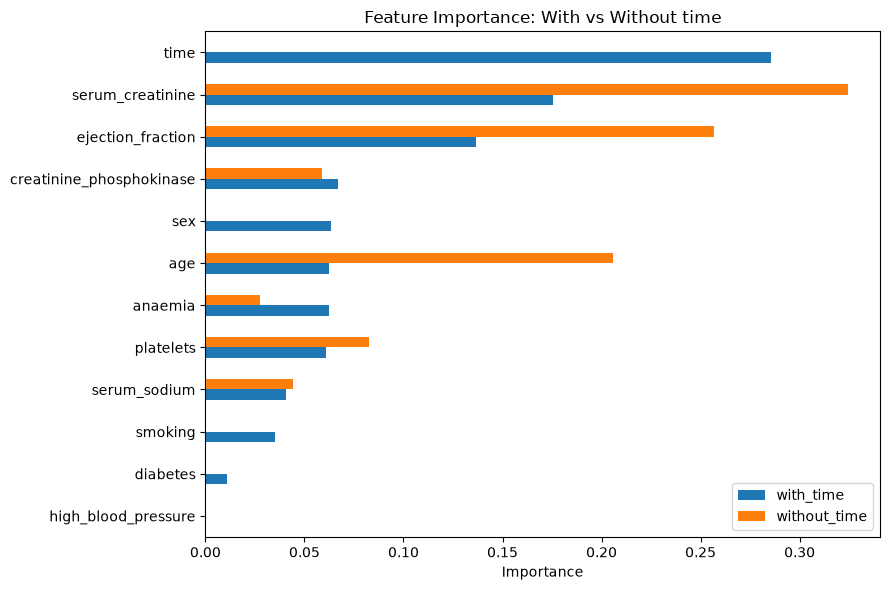

In [39]:
def get_feature_importance(model):
    preprocessor_step = model.named_steps["pre"]
    model_step = model.named_steps["model"]

    return pd.Series(
        model_step.feature_importances_,
        index=preprocessor_step.get_feature_names_out()
    )


importance_with_time = get_feature_importance(best_model)
importance_without_time = get_feature_importance(model_no_time)

importance_comparison = pd.concat(
    [
        importance_with_time.rename("with_time"),
        importance_without_time.rename("without_time")
    ],
    axis=1
).fillna(0)

display(
    importance_comparison.sort_values(
        "with_time",
        ascending=False
    )
)

importance_comparison.sort_values(
    "with_time"
).plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Feature Importance: With vs Without time")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Export Model Result

In [ ]:
MODELS_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\models"
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(best_model, os.path.join(MODELS_DIR, "model.joblib"))

metrics = pd.DataFrame([
    {"metric": "AUC", "value": test_auc},
    {"metric": "F1 (recall optimized)", "value": f1_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "Precision (recall optimized)", "value": precision_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "Recall (recall optimized)", "value": recall_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "scale_pos_weight", "value": float(best_scale_pos_weight)},
    {"metric": "best_threshold", "value": best_t},
    {"metric": "target_recall", "value": float(target_recall)},
    {"metric": "OOF precision at threshold", "value": float(selected["precision"])},
    {"metric": "OOF recall at threshold", "value": float(selected["recall"])},
    {"metric": "OOF F1 at threshold", "value": float(selected["f1"])},
    {"metric": "OOF F2 at threshold", "value": float(selected["f2"])}
])
metrics.to_csv(os.path.join(MODELS_DIR, "metrics_test.csv"), index=False)
candidate_results_df.to_csv(os.path.join(MODELS_DIR, "scale_pos_weight_results.csv"), index=False)
print("Model, metrics & candidates saved to:", MODELS_DIR)

Model, metrics & candidates saved to: D:\Ameng\Data Science Project\heart-failure-prediction\models


In [ ]:
Mpreprocessor = best_model.named_steps["pre"]
joblib.dump(
    preprocessor,
    os.path.join(
        MODELS_DIR,
        "preprocessor.joblib"
    )
)

joblib.dump(
    model_no_time,
    os.path.join(
        MODELS_DIR,
        "xgb_without_time_audit.joblib"
    )
)

time_audit_results.to_csv(
    os.path.join(
        MODELS_DIR,
        "time_feature_audit.csv"
    ),
    index=False
)

print("Main preprocessor saved.")
print("No-time audit model saved.")
print("Time audit metrics saved.")

Main preprocessor saved.
No-time audit model saved.
Time audit metrics saved.
